In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def forward_diff(f,xn,h):
    return (f(xn+h)-f(xn))/h
def backward_diff(f,xn,h):
    return (f(xn)-f(xn-h))/h
def central_diff(f,xn,h):
    return (f(xn+h)-f(xn-h))/(2*h)
def five_point_approx(f,xn,h):
    return (f(xn-2*h)-8*f(xn-h)+8*f(xn+h)-f(xn+2*h))/(12*h)

In [3]:
def f(x):
    return np.sin(x)
xn=(2/5)*(np.pi)
exact=np.cos(xn)
h_val=[0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]

In [4]:
methods = [forward_diff, backward_diff, central_diff, five_point_approx]
print("Table 1: Numerical Derivative Estimates for f(x) = sin(x) at x = 2π/5")
labels = ['Forward', 'Backward', 'Central', 'Five-point']
print('h        Forward         Backward        Central         Five-point      Exact')
for h in h_val:
    fd = forward_diff(f, xn, h)
    bd = backward_diff(f, xn, h)
    cd = central_diff(f, xn, h)
    fpa = five_point_approx(f, xn, h)
    print(f'{h:<10} {fd:<15.10f} {bd:<15.10f} {cd:<15.10f} {fpa:<15.10f} {exact:.10f}')

Table 1: Numerical Derivative Estimates for f(x) = sin(x) at x = 2π/5
h        Forward         Backward        Central         Five-point      Exact
0.5        0.0634494735    0.5291530824    0.2963012779    0.3083920924    0.3090169944
0.2        0.2121719422    0.4017500526    0.3069609974    0.3090005918    0.3090169944
0.1        0.2609890118    0.3560154352    0.3085022235    0.3090159655    0.3090169944
0.05       0.2851167935    0.3326597133    0.3088882534    0.3090169300    0.3090169944
0.02       0.2994861455    0.3185066418    0.3089963937    0.3090169927    0.3090169944
0.01       0.3042566012    0.3137670871    0.3090118441    0.3090169943    0.3090169944
0.005      0.3066380705    0.3113933431    0.3090157068    0.3090169944    0.3090169944
0.002      0.3080657322    0.3099678446    0.3090167884    0.3090169944    0.3090169944
0.001      0.3085414147    0.3094924711    0.3090169429    0.3090169944    0.3090169944
0.0005     0.3087792174    0.3092547456    0.3090169815    

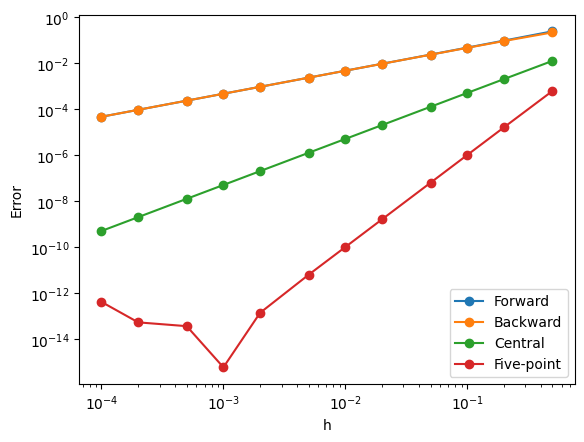

In [27]:
plt.figure()
for method, label in zip(methods, labels):
    errors = [abs(method(f, xn, h) - exact) for h in h_val]
    plt.plot(h_val, errors, 'o-', label=label)

plt.xlabel('h')
plt.ylabel('Error')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

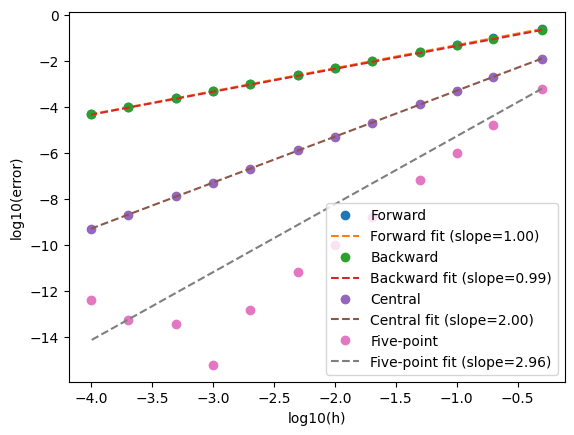

Slopes:
Forward: 1.00
Backward: 0.99
Central: 2.00
Five-point: 2.96


In [34]:
def fit_loglog(h, err):
    x = np.log10(h)
    y = np.log10(err)
    coeffs = np.polyfit(x, y, 1)
    return coeffs[0]

plt.figure()
for method, label in zip(methods, labels):
    errors = [abs(method(f, xn, h) - exact) for h in h_val]
    slope = fit_loglog(h_val, errors)
    log_h = np.log10(h_val)
    log_err = np.log10(errors)
    
    plt.plot(log_h, log_err, 'o', label=label)
    fit_line = slope * log_h + (log_err[0] - slope * log_h[0])
    plt.plot(log_h, fit_line, '--', label=f'{label} fit (slope={slope:.2f})')

plt.xlabel('log10(h)')
plt.ylabel('log10(error)')
plt.legend()
plt.show()

print('Slopes:')
for method, label in zip(methods, labels):
    errors = [abs(method(f, xn, h) - exact) for h in h_val]
    slope = fit_loglog(h_val, errors)
    print(f'{label}: {slope:.2f}')

In [45]:
#Question 2: Numerical Integration

def trapezoidal(fx, h):
    return h * (0.5*fx[0] + fx[1:-1].sum() + 0.5*fx[-1])

def simpson_1_3(fx, h):
    odd = fx[1:-1:2].sum()
    even = fx[2:-2:2].sum()
    return h/3 * (fx[0] + fx[-1] + 4*odd + 2*even)

def simpson_3_8(fx, h):
    idx = np.arange(len(fx))
    s3 = fx[(idx % 3 != 0) & (idx != 0) & (idx != len(fx)-1)].sum()
    s2 = fx[(idx % 3 == 0) & (idx != 0) & (idx != len(fx)-1)].sum()
    return 3*h/8 * (fx[0] + fx[-1] + 3*s3 + 2*s2)

def boole(fx, h):
    weights = np.zeros_like(fx)
    weights[0] = weights[-1] = 7
    for i in range(1, len(fx)-1):
        r = i % 4
        if r == 1 or r == 3:
            weights[i] = 32
        elif r == 2:
            weights[i] = 12
        else:
            weights[i] = 14
    return 2*h/45 * np.sum(weights * fx)

def g(x):
    return np.exp(x)

exact_int = np.exp(1) - 1
M = [4, 8, 16, 32, 64]


In [46]:
# Part (a): Table of Results

# %%
trap_results = []
s13_results = []
s38_results = []
boole_results = []

#for Trapezoidal and Simpson 1/3
for m in M:
    h = 1/(2*m)
    x = np.linspace(0, 1, 2*m + 1)
    fx = g(x)
    trap_results.append(trapezoidal(fx, h))
    s13_results.append(simpson_1_3(fx, h))

#For Simpson 3/8
for m in M:
    h = 1/(3*m)
    x = np.linspace(0, 1, 3*m + 1)
    fx = g(x)
    s38_results.append(simpson_3_8(fx, h))

#For Boole
for m in M:
    h = 1/(4*m)
    x = np.linspace(0, 1, 4*m + 1)
    fx = g(x)
    boole_results.append(boole(fx, h))

print('m     Trapezoidal      Simpson 1/3      Simpson 3/8      Boole')
for i, m in enumerate(M):
    print(f'{m:<5} {trap_results[i]:<16.10f} {s13_results[i]:<16.10f} {s38_results[i]:<16.10f} {boole_results[i]:<16.10f}')

m     Trapezoidal      Simpson 1/3      Simpson 3/8      Boole
4     1.7205185922     1.7182841547     1.7182828626     1.7182818287    
8     1.7188411286     1.7182819741     1.7182818932     1.7182818285    
16    1.7184216603     1.7182818376     1.7182818325     1.7182818285    
32    1.7183167869     1.7182818290     1.7182818287     1.7182818285    
64    1.7182905681     1.7182818285     1.7182818285     1.7182818285    


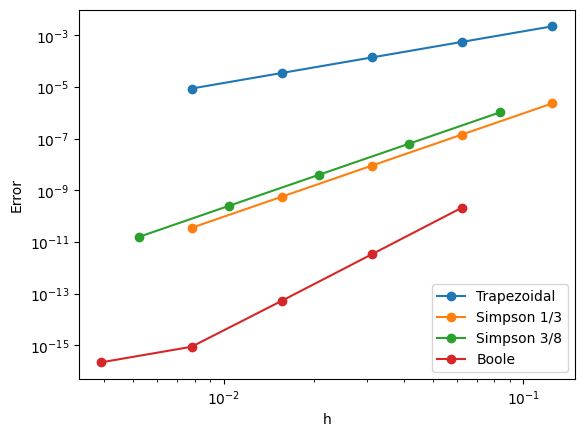

In [48]:
# Part (b): Error Plot
h_trap = [1/(2*m) for m in M]
h_s38 = [1/(3*m) for m in M]
h_boole = [1/(4*m) for m in M]


trap_err = [abs(r - exact_int) for r in trap_results]
s13_err = [abs(r - exact_int) for r in s13_results]
s38_err = [abs(r - exact_int) for r in s38_results]
boole_err = [abs(r - exact_int) for r in boole_results]

plt.figure()
plt.plot(h_trap, trap_err, 'o-', label='Trapezoidal')
plt.plot(h_trap, s13_err, 'o-', label='Simpson 1/3')
plt.plot(h_s38, s38_err, 'o-', label='Simpson 3/8')
plt.plot(h_boole, boole_err, 'o-', label='Boole')
plt.xlabel('h')
plt.ylabel('Error')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [49]:
# Part (c): Efficiency Comparison
print('Slopes:')
for name, h_vals, errors in [
    ('Trapezoidal', h_trap, trap_err),
    ('Simpson 1/3', h_trap, s13_err),
    ('Simpson 3/8', h_s38, s38_err),
    ('Boole', h_boole, boole_err)
]:
    slope = fit_loglog(h_vals, errors)
    print(f'{name}: {slope:.2f}')

Slopes:
Trapezoidal: 2.00
Simpson 1/3: 4.00
Simpson 3/8: 4.00
Boole: 5.17


In [50]:
#Question 3: Integration with Singularities
# The integral has singularities at x=0 and x=1. We use the substitution x = sin^2(theta)

def integrand_transformed(theta):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = 2 * np.sin(theta)**(-1/3) * np.cos(theta)**(1/3)
        result[0] = 0.0
        return result

m = 64
N = 3*m + 1
h = (np.pi/2) / (N-1)
theta = np.linspace(0, np.pi/2, N)
f_theta = integrand_transformed(theta)
I_numerical = simpson_3_8(f_theta, h)
I_exact = 2*np.pi/np.sqrt(3)

print(f'Numerical: {I_numerical:.10f}')
print(f'Exact: {I_exact:.10f}')
print(f'Error: {abs(I_numerical - I_exact):.10e}')

Numerical: 3.5586954304
Exact: 3.6275987285
Error: 6.8903298049e-02
